# Aula 5


# Funções de custo em camadas customizadas


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Apresentar como usar funções de custo em camadas customizadas.

Apresentar exemplos completos de uso de camadas customizadas com custo incluindo o treinamento dos modelos.

### Importação das bilbiotecas básicas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.19.0


## 2. Introdução

Nas aulas anteriores vimos algumas formas de definir funções de custo e customizadas.

Existem outras formas para lidar com funções de custo que não se enquadram nos formatos que vimos nas aulas enteriores.

A grande maioria das funções de custo é calculada a partir das saídas reais e previstas (`y_true` e `y_pred`), mas existem casos onde isso não se aplica. Por exemplo, o cálculo de uma função de custo pode exigir apenas a ativação de uma das camadas da rede, nesse caso não existem valores desejados e essa ativação pode não ser uma saída do modelo.

Nesses casos usam-se camadas customizadas na forma de classe para calcular a função de custo.

## 3. Função de custo na forma de camada customizada

### 3.1 Regularização de ativações

Já vimos metódos de regularização de RNAs baseados no controle da amplitude dos pesos das ligações e viéses (regularização L1 e L2). Existe outra forma de regularização que é aplicar regularização nas ativações das camadas da RNA.

Na regularização das ativações tenta-se diminuir o valor das ativações de forma que seja necessária a contribuição de um maior número de neurônios para a obtenção das saídas da RNA. Isso faz com que grupos de neurônios não se expecializem em determinados exemplos e, assim, tende a aumentar a capacidade de generalização da rede.

Uma função de custo que inclui regularização de ativações na $l$-ésima camada de uma RNA é dada pela seguinte expressão:

$$J_{RA}(W,B) = J(W,B) + \lambda \sum_{k=1}^{n^{[l]}}{a^{[l]}_k}^2$$

onde $J(W,B)$ é a função de custo normal sem regularização, $J_{RA}(W,B)$ é a função de custo com regularização das ativaçõe da l-ésima camada, $W$ e $b$ representam genericamente todos os parâmetros da rede, $\lambda$ é o fator de regularização, $n^{[l]}$ é o número de neurônios da $l$-ésima camada e $a^{[l]}$ são as ativações da $l$-ésima camada.

Nota-se que é possível incluir regularização de ativações em qualquer camada de uma rede. Asim, se for incluida regularização de ativações em outras camadas deve-se incluir os termos correspondentes na equação acima.

Uma forma de incluir o termo de regularização das ativações na função de custo é definir uma camada customizada para calcular a soma das aitvações da camada e adicionar esse termo à função de custo normal.

Para fazer isso, usa-se o método `add_loss(operação)` dentro de uma camada customizada. Observa-se que para usar esse método para incluir o termo de regularização de ativações de uma camada, temos que incluir a operação matemática que define a soma das ativações como argumento do método.  

Quando se usa o método `add_loss()`, o valor calculado por esse custo adicional é adicionado à função de custo principal $J(W,B)$ durante o treinamento. Observe que a função de custo principal consiste na função de custo passada na compilação do modelo.

Vamos mostrar como implementar a regularização de ativações em um problema de classificação multiclasse usando o conjunto de dados Fashion MNIST.

### Codificação da camada com função de custo de regularização de ativações

Para criar o termo adicional da regularização de ativações na função de custo vamos criar uma camada customizada que somente calcula esse custo.

Observa-se que pode usar uma camada customizada para calcular outras coisas além da função de custo adicional.

In [ ]:
# Importa classe de camadas do Keras
from tensorflow.keras import layers

# Camada customizada para regularização de ativações
class ActivityRegularizationLayer(layers.Layer):
    # Inicializa classe e parâmetros
    def __init__(self, lamb=0):
        # Inicializa classe
        super(ActivityRegularizationLayer, self).__init__()
        # Inicializa fator de regularização
        self.lamb = lamb

    # Define operações da camada
    def call(self, inputs):
        # Função de custo é a soma das entradas
        self.add_loss(self.lamb * (tf.reduce_sum(inputs**2)))
        return inputs

- Observa-se que essa camada retorna a sua entrada sem nenhuma modificação.

- O único parâmetro necessário para a operação da camada é o termo de regularização $\lambda$, que é inicializado no método `__init__()`.

- Observa-se que a função de custo adicional é inserida nessa camada com o método `add_loss()`.

- Como a camada não possui nenhum parâmetro, não é necessário incluir o método `build()`.

### 3.2 Dados de treinamento

Vamos carregar o conjunto de dados Fashion MNIST diretamento de Keras, conforme realizado na célula a seguir.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


### 3.3 Codificação one-hot das saídas

Como temos um problema de classificação multiclasse é mais adequado transformar as saídas em vetores one-hot.

In [ ]:
# Transformação das saídas em vetores one-hot
y_train_hot = tf.one_hot(y_train, 10)
y_test_hot = tf.one_hot(y_test, 10)

# Mostra primeiros 5 exemplos de treinamento
print('Saída categórica:', y_train[:5])
print('Saída one-hot:\n', y_train_hot[:5].numpy())

Saída categórica: [9 0 0 3 0]
Saída one-hot:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### 3.4 Configuração da RNA

Para incluir essa função de custo na forma de camada, podemos criar a RNA na forma sequencial ou funcional. Vamos usar a forma funcional.

Vamos criar uma RNA com 3 camadas densas. As duas primeiras com função de ativação ReLu e a camada de saída com função de ativação softmax.

O processamento das imagens será realizado dentro da rede.

Vamos incluir muitos neurônios na rede para termos problema de overfitting.

In [ ]:
# Importa classe de modelos do Keras
from tensorflow.keras.models import Model

# Define fator de regularização de ativações
lamb = 1.0e-4

# Inclui camada de entrada
x0 = layers.Input(shape=(28,28))

# Inclui camada de Flatten
x = layers.Flatten()(x0)

# Inclui camada Lambda de normalização
norm_layer = layers.Lambda(lambda x: (x - 127.5)/127.5)
x = norm_layer(x)

# Inclui 1a camada densa
x = layers.Dense(512, activation="silu", name='dense1')(x)

# Insere camada para calcular função de custo de regularização
x = ActivityRegularizationLayer(lamb=lamb)(x)

# Adiciona 2a camada densa
x = layers.Dense(256, activation="silu", name='dense2')(x)

# Insere camada para calcular função de custo de regularização
x = ActivityRegularizationLayer(lamb=lamb)(x)

# Adiciona camada de saída de classificação
y_pred = layers.Dense(10, activation='softmax', name='saida')(x)

# Define modelo
rna = Model(inputs=x0, outputs=y_pred)

# Sumário do modelo
rna.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_regularization_layer_6 │ (None, 512)            │             0 │
│ (ActivityRegularizationLayer)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_regularization_layer_7 │ (None, 256)            │             0 │
│ (ActivityRegularizationLayer)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

### 3.5 Compilação e treinamento da rede

Para compilar a rede vamos usar a seguinte configuração:

- Otimizador: Adam
- Taxa de aprendizado: 0.001
- Função de custo: `categorical crossentropy`
- Métrica: `accuracy`

Para treinar a rede vamos usar 40 épocas e lotes com 1000 exemplos.

In [ ]:
# Importa classe dos otimizadores
from tensorflow.keras import optimizers

# Compilação da rede
adam = optimizers.Adam(learning_rate=0.001)
rna.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# treinamento da rede
results = rna.fit(x_train, y_train_hot, batch_size=1000, epochs=40, validation_data=(x_test, y_test_hot))

Epoch 1/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6086 - loss: 5.9856 - val_accuracy: 0.8014 - val_loss: 2.3099
Epoch 2/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8242 - loss: 2.0394 - val_accuracy: 0.8242 - val_loss: 1.6101
Epoch 3/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8363 - loss: 1.5012 - val_accuracy: 0.8133 - val_loss: 1.3793
Epoch 4/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8455 - loss: 1.2619 - val_accuracy: 0.8307 - val_loss: 1.2033
Epoch 5/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8515 - loss: 1.1290 - val_accuracy: 0.8366 - val_loss: 1.1003
Epoch 6/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8577 - loss: 1.0331 - val_accuracy: 0.8368 - val_loss: 1.0475
Epoch 7/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8562 - loss: 0.9820 - val_accuracy: 0.8444 - val_loss: 0.9692
Epoch 8/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8627 - loss: 0.9086 - val_accuracy: 0.8473 - val_loss

#### Gráfico do processo de trienamento

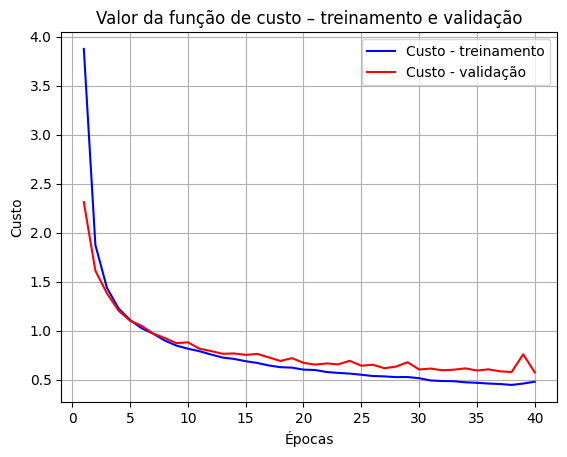

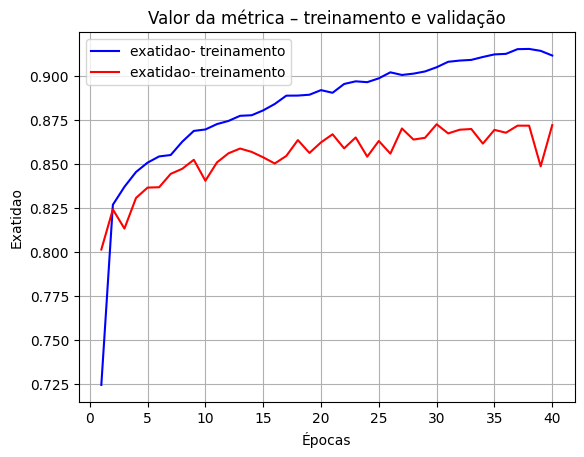

In [ ]:
def plot_train(history):# Salva treinamento na variável history para visualização
    history_dict = history.history

    # Salva custos, métricas e epocas em vetores
    custo = history_dict['loss']
    acc = history_dict['accuracy']
    val_custo = history_dict['val_loss']
    val_acc = history_dict['val_accuracy']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.plot(epocas, val_custo, 'r', label='Custo - validação')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.legend()
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
    plt.plot(epocas, val_acc, 'r', label='exatidao- treinamento')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Exatidao')
    plt.legend()
    plt.grid()
    plt.show()

plot_train(results)

### 3.6 Avaliação e teste da RNA

Para avaliar o desempenho da RNA vamos calcular a função de custo e a métrica e também calcular as saídas previstas e fazer um gráfico com as saídas reais e previstas para poder compará-las.

In [ ]:
# Calcula função de custo e métrica
rna.evaluate(x_train, y_train_hot)
rna.evaluate(x_test, y_test_hot)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9212 - loss: 0.2391
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8708 - loss: 0.3888


[0.3878228962421417, 0.8720999956130981]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


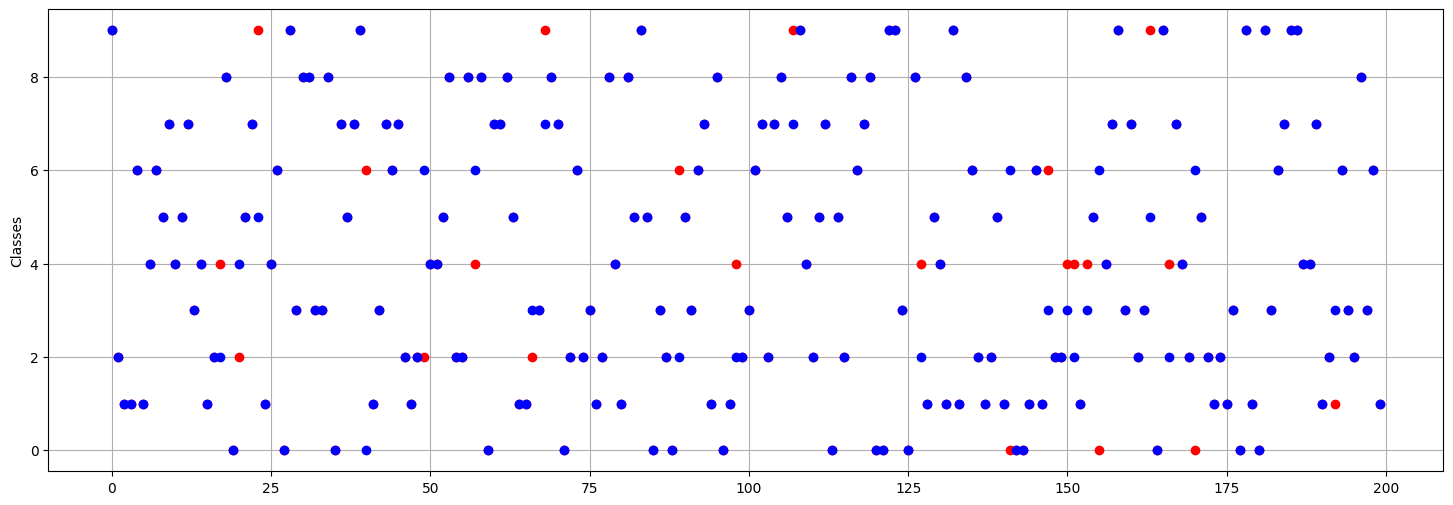

In [ ]:
# Calcula saídas previstas
y_prev = rna.predict(x_test)

# Indentifa classe prevista
class_prev = np.argmax(y_prev, axis=1)

# Gráfico dos resultados
#plt.scatter(x, y)
plt.figure(figsize=(18,6))
plt.plot(y_test[:200], 'ro', label='Saídas reais')
plt.plot(class_prev[:200], 'bo', label='Saídas previstas')
plt.ylabel('Classes')
plt.grid()
plt.show()

**Qual é a influência do fator de regularição das ativações $\lambda$ para eliminar overfitting?**